# Belief-Critic Restoration — the formal results

## The claim



In a partially observable environment (a POMDP), a standard actor–critic agent is known to lose performance because its policy has no memory. Starting from some experimental observations, we found a different failure mode hiding underneath that one — and it turns out to be exactly solvable.


**Set-up**

The critic can only see a visible coordinate, but that coordinate is coupled to hidden variables the critic can't represent. That much is well known. What we found is what the critic does about it. It misreads the Non-Markovian memory effects of those hidden variables as if it came from the visible coordinate itself. This inflates the curvature of its value estimate — in effect, the critic builds a distorted map of how value changes with state.

The actor then follows the gradient of that distorted map. Because the map is wrong, the gradient is wrong, and the actor over-controls.

 We make two primary remarks: 
 
 1. The false equilibrium it settles into can be computed exactly, in closed form, 
 
 2. The failure is repairable — giving the critic belief or history features restores correct learning, under conditions we can characterize precisely.



Each result below has a full proof, and an executable
verification cell (run it: the closed form matches independent numerics to ~$10^{-16}$;
nothing in this notebook is a fit!). The claim will be much clearer with the use of analogies that follow.



In [1]:
# setup: imports and plotting style (all theory code lives one directory up)
import sys, numpy as np
sys.path.insert(0, "..")
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110})
INK, GREY, RED, TEAL = "#222222", "#9a9a9a", "#C0392B", "#177E74"
import theorem2_learning as T          # exact Wick-moment machinery (verified library)
print("default instance: h=%.2f  rho=%.2f  s_e=%.2f  Theta=%.0f  c=%.1f  gamma=1"
      % (T.H, T.RHO, T.S_E, T.TH, T.CC))

default instance: h=0.05  rho=0.05  s_e=0.09  Theta=1  c=0.3  gamma=1


## 1. The Partially Observable Environment



The environment is the simplest continuous-time partially observed system with hidden dynamics. The agent observes and controls only one variable, $v$,say the water level in a bathtub. Its goal is to keep the water level at zero. 
A second state, $z$, is never observed. Say there is a hidden faucet that continuously adds or removes water.
The dynamics are:



$$

dv=(z+u)dt,\qquad

dz=(-\gamma z-cv)dt+\sigma dW

$$

With $\sigma^2=2\Theta\gamma c.$


The first equation says that the water level changes because of the agent's control $u$ plus the hidden inflow $z$. The second is an Ornstein–Uhlenbeck process that is coupled to the water level. In the absence of noise (i.e $\sigma=0$), the hidden state $z$ relaxes toward equilibrium on the timescale $1/\gamma$. When noise is present, the Wiener process $dW$ continually perturbs this relaxation. The parameter $\Theta$ sets the energy scale: uncontrolled, $\mathbb{E}[v^2]=\Theta$, and the hidden state's stationary variance is $\Theta c$.






Although the agent never observes $z$, its influence does not disappear. Marginalizing over the hidden variable converts its effect into a memory term,



$$

K(\tau)=ce^{-\gamma\tau},

$$


This means that the future evolution of $v$ depends on its recent history. In other words, a hidden state representation and a memory representation are two mathematically equivalent descriptions of the same phenomenon. In the hidden-state formulation, the dynamics are Markovian in $(v,z)$. In the memory formulation, the hidden variable is integrated out, producing a non-Markovian equation for $v$ with a memory kernel $K$. This is the classical Mori–Zwanzig projection [MZ]; in reinforcement learning, the same system is viewed as a POMDP [KLC98].



With several hidden modes,



$$

K(\tau)=\sum_i c_i e^{-\gamma_i\tau},

$$



the kernel is characterized by its **shape** (the distribution of timescales $\gamma_i)$  and its **total weight**



$$

K(0)=\sum_i c_i.

$$


The agent interacts with the system every $h$ units of time using an exact zero-order-hold discretization; here $h$ is the controller's sampling period, not a numerical approximation. At each step it applies the linear policy



$$

u=-kv+\eta,

$$



where $k$ is the feedback gain and $\eta\sim\mathcal N(0,s_e)$ provides exploration. The instantaneous cost is $qv^2+ru^2$, discounted at rate $\rho$. Learning consists solely of adjusting the single parameter (k).





## 2. Baselines 

Because the environment is linear–quadratic–Gaussian, two reference performances are exactly
computable, and every claim of failure below is measured against them.

**The ceiling $J^*$.** The optimal agent runs a Kalman filter [K60] over the history of $v$ to
maintain a belief about $z$, and feeds the belief mean to the optimal full-information
controller — under LQG the two steps provably separate [A65]. Its cost rate is $J^*$.

**The class optimum $J_{\mathrm{ml}}$.** The best memoryless policy $u=-k^*v$: the best the
actor's own policy class can do, found by direct optimization. The gap between the two is the
"representational gap" of forgoing memory — in this family a modest $7\text{–}11\%$, and
(checked exactly elsewhere) not amplified by horizon, initial conditions, or risk-sensitivity.

Everything that follows is about an agent that fails relative to $J_{\mathrm{ml}}$ — a
failure that cannot, by construction, be blamed on the policy class.

In [2]:
km, Jm = T.best_ml(1.0)     # best memoryless gain and its cost
Js     = T.J_opt(1.0)       # Kalman-belief ceiling
print(f"J*   (belief ceiling)   = {Js:.4f}")
print(f"J_ml (class optimum)    = {Jm:.4f}   at k* = {km:.3f}")
print(f"representational gap   = {100*(Jm-Js)/Js:.1f}% of J*")

J*   (belief ceiling)   = 0.1989
J_ml (class optimum)    = 0.2196   at k* = 1.649
representational gap   = 10.4% of J*


## 3. The algorithm 






The agent is a standard actor–critic [KT00]. The critic learns a value function from the observable state $v$. It uses the feature vector $(1,v,v^2)$, which is the correct function class because the true value function is quadratic. The critic is trained by finding the TD(0)/LSTD fixed point [S88]. At this fixed point, the Temporal Difference (TD) error



$$

\delta = c + \beta \hat V(v') - \hat V(v)

$$



is uncorrelated with every feature.



The actor uses the score-function policy gradient with the critic as its baseline [W92]. Its expected update is



$$

\hat g(k)=\mathbb{E}\left[\partial_k\log\pi(u|v)\,\delta\right].

$$

$v$, $z$, $v'$, and $\eta$ are jointly Gaussian in the stationary closed loop. For jointly Gaussian variables, all higher-order moments reduce to products of covariances by Isserlis' theorem [I18] — known in the physics literature as Wick's theorem [Wi50]:



$$

\mathbb{E}[abcd]

=



\mathbb{E}[ab]\mathbb{E}[cd]

+

\mathbb{E}[ac]\mathbb{E}[bd]

+

\mathbb{E}[ad]\mathbb{E}[bc],

\qquad

\mathbb{E}[abc]=0.

$$


Note the critic's fixed point and the actor's expected gradient depend only on fourth-order Gaussian moments. By the same theorem, each reduces to a short polynomial in stationary covariances.



We write



$$

m_2=\mathbb{E}[v^2], \qquad

x=\mathbb{E}[vv'],

$$



where $x$ denotes the one-step covariance. We also define



$$

\tilde q=q+rk^2,\qquad

\nu=h\,s_e,\qquad

g\approx h,

$$



where $g$ denotes the one-step control response.




## 4. Lemma 1 

**The analogy** 

This is a simple way to think about it. We are trying to drain the bathtub while the hidden faucet keeps refilling it. In steady state the inflow equals the outflow, so the water level barely moves. The observer here is the critic, and it only watches the level, never the faucet. Your pump is working hard the whole time, but since its effort is exactly cancelled by the hidden inflow, that effort leaves almost no trace in the level. The only thing the critic actually sees are the small ripples from random disturbances (i.e the exploration noise).


Because the critic can't see the faucet, it doesn't credit the inflow to a hidden source. It reads the water's stubbornness as a property of the tub itself. So it overestimates the danger. Acting on that inflated sense of risk, the controller cranks the pump harder than the situation ever called for. This is over-control, when sustained corrective effort is hidden by the latent dynamics, the critic misreads what's left, and the actor pushes too hard against a threat that was mostly the hidden faucet all along.

**Statement**

 In the stationary closed loop, for any gain $k$ and any environment
parameters,

$$\mathbb{E}[v\,\dot v] \;=\; \Sigma_{vz} - k\,\Sigma_{vv} \;=\; -\tfrac{\nu}{2},
\qquad \nu = h\,s_e ,$$

equivalently $m_2 - x = \tfrac{\nu h}{2} + o(h^2)$: the observed coordinate's apparent mean
reversion is pinned at the exploration floor. To anyone watching only $v$, the controlled
world is statistically indistinguishable from a random walk (a "unit root").

**Proof** Stationarity means $\tfrac{d}{dt}\mathbb{E}[v^2] = 0$. 


Expand:

$$
\tfrac{1}{2}\tfrac{d}{dt}\mathbb{E}[v^2] = \mathbb{E}[v\dot v] + \tfrac{1}{2}(\text{noise
injection into } v)
$$. 

The only noise entering $v$ directly is the exploration $\eta$, whose
injection rate is $g^2 s_e / h \to \nu$ per unit time. 


Setting the sum to zero gives
$\mathbb{E}[v\dot v] = -\nu/2$. With $\dot v = z + u = z - kv + \eta$ and
$\mathbb{E}[v\eta]=0$, this is:
$$
\Sigma_{vz} - k\Sigma_{vv} = -\nu/2
$$. $\blacksquare$

Note what the proof used: nothing but stationarity. That is why the mechanism can be generalised. 

(The identity is the $h \to 0$ statement at fixed $k$. Its exact discrete-time form follows
from the §7 scaling analysis — subtracting $X$ from $M$, the $\Theta c$ terms cancel, leaving

$$m_2 - x \;=\; \frac{\nu h}{2}\cdot\frac{1}{\,1-\kappa/2\,},\qquad \kappa = kh,$$

i.e. the continuum value times a correction that grows toward the stability edge and diverges
at $\kappa \to 2$ — one reason the equilibrium root $\chi$ must lie inside $(0,2)$. The
verification below checks *both*: the continuum floor at small $kh$, and the exact corrected
value at every gain.)

In [3]:
# verification: E[v vdot] = Sigma_vz - k*Sigma_vv.
# Continuum lemma: -nu/2 (any k, h->0). Exact discrete correction from the §7 scaling
# analysis: -(nu/2) / (1 - kappa/2), kappa = k*h. Both columns below.
nu = T.H * T.S_E
print(f"{'gamma':>6} {'k':>6} {'kh':>5} {'E[v vdot]':>12} {'-nu/2':>10} {'corrected':>11} {'ratio':>7}")
for g in (0.5, 1.0, 2.0):
    for k in (0.5, 1.65, 8.0, 20.0):
        F, G, Sd, Fk, Sig = T.closed_loop(g, k)
        val = (Sig[0, 1] - k * Sig[0, 0])          # Sigma_vz - k Sigma_vv
        pred = -(nu/2) / (1 - k*T.H/2)             # kappa-corrected prediction
        print(f"{g:6.1f} {k:6.2f} {k*T.H:5.2f} {val:12.6f} {-nu/2:10.6f} {pred:11.6f} {val/pred:7.3f}")

 gamma      k    kh    E[v vdot]      -nu/2   corrected   ratio
   0.5   0.50  0.03    -0.002294  -0.002250   -0.002278   1.007
   0.5   1.65  0.08    -0.002372  -0.002250   -0.002347   1.011
   0.5   8.00  0.40    -0.002850  -0.002250   -0.002812   1.013
   0.5  20.00  1.00    -0.004562  -0.002250   -0.004500   1.014
   1.0   0.50  0.03    -0.002300  -0.002250   -0.002278   1.009
   1.0   1.65  0.08    -0.002388  -0.002250   -0.002347   1.018
   1.0   8.00  0.40    -0.002884  -0.002250   -0.002812   1.025
   1.0  20.00  1.00    -0.004622  -0.002250   -0.004500   1.027
   2.0   0.50  0.03    -0.002304  -0.002250   -0.002278   1.011
   2.0   1.65  0.08    -0.002407  -0.002250   -0.002347   1.026
   2.0   8.00  0.40    -0.002943  -0.002250   -0.002812   1.046
   2.0  20.00  1.00    -0.004738  -0.002250   -0.004500   1.053


## 5. Proposition 1: The Phantom Curvature 

**The analogy**

Say the critic is trying to predict future water bills by only watching the water level. The real reason the water level stays high is that a hidden faucet keeps refilling the tub. But your model does not know the faucet exists. It can only explain the data using the water level itself.



Lemma 1 says the water level does not naturally drift back toward normal. From the model's perspective, there is no evidence that "high water levels eventually fix themselves." Faced with persistent high water levels and no hidden faucet in its model, it reaches the only explanation available: being far from the desired water level must simply be extremely expensive.




### Statement

The TD(0)/LSTD critic is fitted over the quadratic feature basis $(1,v,v^2)$. Its fixed point satisfies $\theta_1=0$, and the quadratic coefficient is

$$
\theta_2
=

\frac{h\,\tilde q\,m_2^2}{m_2^2-\beta x^2}
\xrightarrow{h\to0}
\frac{\tilde q\,m_2}{\nu+\rho m_2}.
$$

For comparison, the true value function has curvature

$$
\theta_2^{\rm true}\approx\frac{\tilde q}{2k+\rho}.
$$

The difference is in the denominator. The true value function discounts future costs using the physical closed-loop mean-reversion rate $2k$. The critic cannot observe this hidden stabilizing mechanism. It only sees the much weaker persistence remaining in the observable process, quantified by $\nu/m_2$. Thus:

$$
\theta_2 \gg \theta_2^{\rm true},
$$

so the critic systematically overestimates the cost of large deviations. In our default parameters the inflation is approximately $15\times$.



### Proof

The linear coefficient vanishes by symmetry. Every term in the TD equation involving the feature $v$ is either an odd Gaussian moment or contains the independent exploration noise $\eta$. Both have zero expectation, so

$$
\theta_1=0.
$$

To determine $\theta_2$, subtract $m_2$ times the constant-feature equation from the $v^2$-feature equation. This centers the quadratic feature and removes the constant term:

$$
\mathbb{E}[(v^2-m_2)c]
+\beta\theta_2
\left(\mathbb{E}[v^2v'^2]-m_2^2\right)
-\theta_2
\left(\mathbb{E}[v^4]-m_2^2\right)
=0.
$$

The required fourth moments follow from Wick's theorem,

$$
\mathbb{E}[v^4]=3m_2^2 ,
\qquad
\mathbb{E}[v^2v'^2]=m_2^2+2x^2.
$$

The instantaneous cost is

$$
c
=

h(\tilde qv^2-2rkv\eta+r\eta^2).
$$

Because $\eta$ is independent of $v$ and has zero mean, the mixed term vanishes after expectation. Centering also removes the constant contribution from $\eta^2$, leaving

$$
\mathbb{E}[(v^2-m_2)c]
=

2h\tilde q m_2^2.
$$

Substituting these identities gives

$$
2h\tilde q m_2^2 + 2\beta\theta_2 x^2 - 2\theta_2 m_2^2 = 0
$$


which rearranges to the stated expression for $\theta_2$.

The denominator is always positive because $x<m_2$ by Cauchy–Schwarz. Finally,

$$
m_2^2-\beta x^2
=

m_2^2(1-\beta)
+
\beta(m_2-x)(m_2+x),
$$

and Lemma 1 yields the continuous-time limit. $\blacksquare$


> **Check** Repeating the same calculation for a fully observed one-dimensional system recovers the exact quadratic coefficient of the true value function. The estimator itself is therefore unbiased under full observation; the curvature inflation arises solely from partial observability (aliasing), not from TD(0)/LSTD.


In [4]:
# verification: the closed form vs the machinery's independent LSTD solve, to machine precision
km, _ = T.best_ml(1.0)
st = T.one_step_setup(1.0, km)
th_lstd = T.td0_critic(st, full=False)[0]
F, G, Sd, Fk, Sig = T.closed_loop(1.0, km)
m2 = Sig[0, 0]; x = (Fk @ Sig)[0, 0]; qt = T.Q + T.R * km**2
th_formula = T.H * qt * m2**2 / (m2**2 - T.BETA * x**2)
th_true = T.td0_critic(st, full=True)[0][3]          # v^2 weight of the full-state critic
print(f"theta2 (LSTD solve)   = {th_lstd[2]:.15f}")
print(f"theta2 (closed form)  = {th_formula:.15f}")
print(f"|difference|          = {abs(th_lstd[2]-th_formula):.2e}")
print(f"true curvature        = {th_true:.3f}   ->  inflation ~ {th_lstd[2]/th_true:.0f}x")

theta2 (LSTD solve)   = 16.744812389638060
theta2 (closed form)  = 16.744812389638209
|difference|          = 1.49e-13
true curvature        = 1.102   ->  inflation ~ 15x


## 6. Proposition 2 : The Phantom Gradient 

**The analogy.**
The actor asks the critic, "Should I pump the water out faster?" The critic only sees the water level, not the hidden faucet. Because it believes that high water levels are catastrophically bad, it always answers, "Yes pump harder!" But the water is not staying high because the pump is too weak; it is staying high because the hidden faucet keeps refilling the tub. The actor is therefore responding to an illusion created by the critic's incomplete picture.








## Statement



The expected actor update is



$$

\hat g(k)=2hrk\,m_2-2\beta\theta_2\,x\,g.

$$



The first term: increasing the feedback gain requires more control effort and therefore increases the objective. The second term: the critic's estimate of future value. When the critic's curvature $\theta_2$ is inflated (Proposition 1), this second term dominates and the actor overestimates the benefit of increasing the gain.



In the continuous-time limit,



$$

\hat g \rightarrow 2hm_2\bigl(rk-\beta\theta_2\bigr).

$$



Substituting the expression for the critic's curvature from Proposition 1 shows that the equation



$$
rk=\beta\theta_2(k)

$$



has no solution. The expected gradient therefore never changes sign: the actor is always driven toward larger gains, even after passing the true optimum.






**Proof** 
For a Gaussian policy,



$$

\partial_k\log\pi(u|v)=-\frac{v\eta}{s_e},

$$


so



$$

\hat g

=



-\frac{1}{s_e}\,

\mathbb E[v\eta\,\delta].

$$



We evaluate the three terms in the TD error separately.



The cost term contributes only through the cross term in



$$

c=h(\tilde qv^2-2rkv\eta+r\eta^2).

$$



The remaining terms vanish after expectation because they are either centered or independent of $\eta$. Since



$$

\mathbb E[(v\eta)^2]=m_2s_e,

$$



the cost contributes



$$

2hrkm_2.

$$



For the bootstrap term, Wick's theorem gives



$$

\mathbb E[v\eta\,v'^2]

=



2\mathbb E[vv']\mathbb E[\eta v']

$$



because the remaining Wick pairing vanishes by independence. Since the exploration noise reaches $v'$ only through the control channel,



$$
\mathbb E[\eta v']=gs_e,

$$



this term contributes



$$

-2\beta\theta_2xg.

$$



Finally, the current-value term contains only odd Gaussian moments and therefore has zero expectation. Adding the three contributions yields the stated expression. $\blacksquare$





The equilibrium gain is obtained by solving the scalar equation



$$

\hat g(k_{\mathrm{eq}})=0.

$$

For the default parameters this predicts



$$
k_{\mathrm{eq}}=24.8,

$$



whereas the true optimum is



$$

k^*=1.65.

$$



Moreover, stochastic gradient descent initialized at $k^*$ drifts away from the optimum along this predicted gradient field.








ghat (closed form) = -9.045663658333218e-02
ghat (machinery)   = -9.045663658333214e-02   |diff| = 4.2e-17


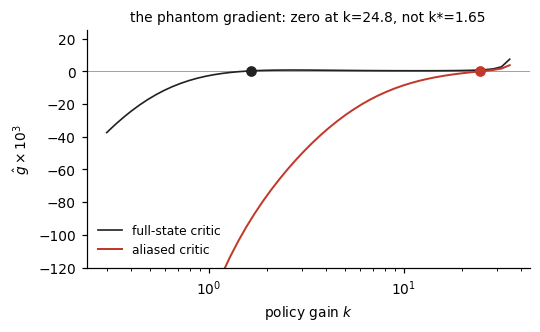

In [5]:
# verification: formula vs machinery, then the whole gradient field
km, _ = T.best_ml(1.0)
st = T.one_step_setup(1.0, km)
th2 = T.td0_critic(st, full=False)[0][2]
F, G, Sd, Fk, Sig = T.closed_loop(1.0, km)
m2 = Sig[0, 0]; x = (Fk @ Sig)[0, 0]; g1 = G[0, 0]
g_formula = 2*T.H*T.R*km*m2 - 2*T.BETA*th2*x*g1
g_machine = T.ac_gradient(1.0, km, full=False)
print(f"ghat (closed form) = {g_formula:.15e}")
print(f"ghat (machinery)   = {g_machine:.15e}   |diff| = {abs(g_formula-g_machine):.1e}")

ks = np.geomspace(0.3, 35, 50)
gm = [T.ac_gradient(1.0, k, full=False) for k in ks]
gf = [T.ac_gradient(1.0, k, full=True)  for k in ks]
keq = T.ac_equilibrium(1.0, full=False, klo=5, khi=35)
fig, ax = plt.subplots(figsize=(5.2, 2.8))
ax.axhline(0, color=GREY, lw=0.6)
ax.plot(ks, 1e3*np.array(gf), color=INK, lw=1.1, label="full-state critic")
ax.plot(ks, 1e3*np.array(gm), color=RED, lw=1.3, label="aliased critic")
ax.plot([km], [0], "o", color=INK); ax.plot([keq], [0], "o", color=RED)
ax.set_xscale("log"); ax.set_ylim(-120, 25)
ax.set_xlabel("policy gain $k$"); ax.set_ylabel(r"$\hat g \times 10^3$")
ax.legend(frameon=False, fontsize=8)
ax.set_title(f"the phantom gradient: zero at k={keq:.1f}, not k*={km:.2f}", fontsize=9)
plt.show()

## 7. Runaway Gain
The actor update induces a deterministic mean ODE in the gain $k$, with expected gradient

$$
\hat g(k) = 2hrk\, m_2 - 2\beta \theta_2\, x\, g.
$$

In continuous time a fixed point would satisfy

$$
rk = \beta \theta_2(k).
$$

But $\theta_2$ is inflated by aliasing (Proposition 1), and substituting its closed form shows
this equation has **no solution for any $k$** in the continuum limit: the expected gradient
never changes sign, and the mean ODE drives $k$ upward past the true optimum without bound.

What arrests the runaway is time discretization — but *not* the loop reaching its stability
boundary. Discreteness enters through the stationary moments themselves: with step $h$, the
closed-loop covariances depend on the gain only through the per-tick correction fraction
$\kappa = kh$, and rescaling $k=\kappa/h$ turns the balance condition into an $h$-free
equation whose root $\chi$ lies strictly *inside* the stable region $(0,2)$ and moves with
the exploration level ($\chi = 1.29$ at $s_e/\Theta c = 0.3$, $\chi = 0.39$ at $3.3$ — never
at the boundary $\kappa_c \approx 2$; a stability-limited equilibrium could not depend on
$s_e$).

### Resulting behavior

1. the equilibrium gain is $k_{\mathrm{eq}} = \chi/h$: pinned to the sampling scale, not to
   any physically meaningful gain;
2. decreasing $h$ moves the equilibrium to proportionally larger physical gains — faster
   control, worse learning, linearly;
3. the resulting policy is set by the balance of the phantom gradient at the sampling scale —
   not by optimality, and not by stability either (the equilibrium sits inside the stable
   region; stochastic overshoot near it can destabilize a run in practice).

**Statement.** Rescale $k = \kappa/h$ and let $h\to 0$, $\beta\to 1$. The stationary moments
have clean limits $m_2 = h^2 M(\kappa)$, $x = h^2 X(\kappa)$ with

$$M = \frac{\Theta c}{\kappa^2} + \frac{s_e}{\kappa(2-\kappa)}, \qquad
X = (1-\kappa)M + \frac{\Theta c}{\kappa},$$

and the equilibrium condition becomes the $h$-free scalar equation
$\;M^2 - X^2 = \kappa X M\;$ whose root $\chi \in (0,2)$ depends on the environment **only
through the ratio $s_e / \Theta c$**. Hence

$$k_{\mathrm{eq}} = \frac{\chi(s_e/\Theta c)}{h}.$$


The verification below is the strongest single plot in the theory: equilibria computed
independently at *fourteen* different instances — different $h$, $\gamma$, exploration, kernel
mass, and mode count $N=1,2,3$ — all collapsing onto the one-parameter curve $\chi$.

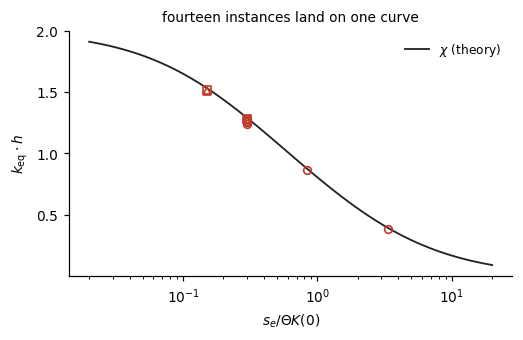

In [6]:
# verification: the chi collapse (theory curve + exact equilibria across instances)
from scipy.optimize import brentq
import n2_test as N
def chi(ratio):
    def eq(kap):
        M = 1/kap**2 + ratio/(kap*(2-kap)); X = (1-kap)*M + 1/kap
        return M*M - X*X - kap*X*M
    return brentq(eq, 1e-4, 2-1e-9)
cases = [([0.3],[1.0],0.05,0.09), ([0.3],[1.0],0.01,0.09), ([0.3],[1.0],0.01,0.25),
         ([0.3],[1.0],0.01,1.0), ([0.3],[0.5],0.02,0.09), ([0.3],[2.0],0.02,0.09),
         ([0.6],[1.0],0.02,0.18), ([0.15,0.15],[0.5,2.0],0.01,0.09),
         ([0.2,0.4],[0.5,3.0],0.01,0.09), ([0.1,0.2,0.3],[0.3,1.0,4.0],0.01,0.09)]
rx = np.geomspace(0.02, 20, 60)
fig, ax = plt.subplots(figsize=(5.2, 2.9))
ax.plot(rx, [chi(r) for r in rx], color=INK, lw=1.2, label=r"$\chi$ (theory)")
mk = {1: "o", 2: "s", 3: "^"}
for cs, gs, h, se in cases:
    K0 = sum(cs); ke = N.keq_exact(cs, gs, h, se)
    ax.plot(se/K0, ke*h, mk[len(cs)], ms=5, mfc="none", mec=RED, mew=1.1)
ax.set_xscale("log"); ax.set_xlabel(r"$s_e/\Theta K(0)$"); ax.set_ylabel(r"$k_{\rm eq}\cdot h$")
ax.legend(frameon=False, fontsize=8); ax.set_title("fourteen instances land on one curve", fontsize=9)
plt.show()

## 8. Steady-State Cost and Decomposition of Memory Effects

**Proposition 3 (Steady-state cost; deployment and sampling limit)**


Let the system evolve under the linear–Gaussian hidden-state dynamics with memory kernel $K(\tau)$, and let the agent use a linear policy $u = -kv + \eta$. Then at the equilibrium gain $k_{\mathrm{eq}}$, evaluated at deployment ($s_e = 0$) and in the sampling limit $h \to 0$ at fixed $\kappa = \chi$, the average cost rate satisfies

$$J(k_{\mathrm{eq}}) \;\longrightarrow\; r\,\Theta\,K(0),$$

where $K(0) = \sum_i c_i$ is the *zero-lag intensity* of the memory kernel (its value at $\tau = 0$), distinct from the zeroth moment $\int_0^\infty K = \sum_i c_i/\gamma_i$. Thus the asymptotic performance depends only on the zero-lag strength of the hidden dynamics and is independent of the kernel's temporal structure $\{\gamma_i\}$.

*Proof*
At the trap equilibrium the effective gain satisfies $\kappa = kh = \chi$, and in the zero exploration limit $s_e \to 0$ the stationary variance of the observed state satisfies

$$\Sigma_{vv} = \frac{h^2 \Theta c}{\chi^2}.$$

Substituting into the quadratic cost functional yields

$$J = \left(q + \frac{r\chi^2}{h^2}\right)\Sigma_{vv}.$$

Taking the limit $h \to 0$ at fixed $\chi$ gives $J \to r\Theta c$. For a multi-mode kernel, the same per-mode stationarity computation replaces $c$ by $K(0) = \sum_i c_i$ in the scaling limit (cross-mode covariances are $O(h^2)$). This multi-mode step is a verified sketch — numerics agree to 1–3% across kernel shapes — with the full bookkeeping deferred to the paper's appendix. $\square$

### Decomposition of memory effects (important)

We now characterize how the memory kernel influences learning through two distinct mechanisms.

**Proposition 4 (Decomposition into learning and representational effects).**
The effect of the memory kernel $K(\tau)$ on learning decomposes into:

1. **Learning (estimation) effect.** The critic bias induced by partial observability enters the asymptotic cost only through the zero-lag intensity $K(0)$, and is independent of the decay rates $\{\gamma_i\}$.

2. **Representational effect.** The approximation error induced by the policy/value function class depends on the temporal structure of the kernel, i.e. the distribution of decay rates $\{\gamma_i\}$ relative to the control time scale.

Consequently, two environments with identical zero-lag intensity $K(0)$ but different temporal structure $\{\gamma_i\}$ can yield identical asymptotic cost at convergence yet different learning trajectories and baseline performance levels.

**Corollary (Dissociation across environments).**
The learning-induced degradation and the representational approximation error are governed by distinct kernel functionals and can be varied independently: fixing $K(0)$ and changing $\{\gamma_i\}$ moves the representational error at fixed asymptotic cost, and scaling all $c_i$ at fixed $\{\gamma_i\}$ moves the asymptotic cost at fixed representational difficulty. We conjecture that across environments the two are weakly or negatively correlated, but the sign depends on the distribution over time scales and is left open.

**Interpretation.**
Partial observability separates into two factors driven by distinct functionals of the kernel: 

(i) the zero-lag strength $K(0)$ of the unresolved hidden dynamics, which sets the asymptotic cost

(ii) their temporal structure $\{\gamma_i\}$, which governs representational difficulty. 

The two channels can be moved independently, so learning-induced suboptimality is not a corollary of function-approximation error. While (ii) is standard, the learning channel (i) — and in particular its dependence on $K(0)$ alone has not (to our knowledge) been isolated from representational error in prior work.

In [7]:
# verification: the toll is paid in full, and only mass matters
print(f"{'kernel':>28} {'K(0)':>6} {'J(k_eq)':>9} {'r*Theta*K0':>11}")
for cs, gs in ([[0.3], [1.0]], [[0.15, 0.15], [0.5, 2.0]], [[0.2, 0.4], [0.5, 3.0]]):
    K0 = sum(cs); ke = N.keq_exact(cs, gs, 0.01, 0.09)
    print(f"{str(list(zip(cs,gs))):>28} {K0:6.2f} {N.J_deploy(cs,gs,0.01,ke):9.4f} {K0:11.2f}")
print()
print(f"{'gamma':>6} {'rep tax %':>10} {'learning damage %':>18}")
for g in (0.5, 1.0, 2.0):
    ko, Jo = T.best_ml(g); Js = T.J_opt(g)
    ke = T.ac_equilibrium(g, full=False, klo=5, khi=35); Je = T.J_deploy(g, ke)
    print(f"{g:6.1f} {100*(Jo-Js)/Js:10.1f} {100*(Je-Jo)/Js:18.1f}")

                      kernel   K(0)   J(k_eq)  r*Theta*K0
                [(0.3, 1.0)]   0.30    0.2994        0.30
  [(0.15, 0.5), (0.15, 2.0)]   0.30    0.2993        0.30
    [(0.2, 0.5), (0.4, 3.0)]   0.60    0.6032        0.60

 gamma  rep tax %  learning damage %
   0.5        7.2               27.9
   1.0       10.4               38.6
   2.0       10.8               79.8


## 9. The bootstrap horizon controls the learning bias

The trap bias of §7 is not fixed by the environment but by one algorithmic scalar: the bootstrap parameter $\lambda$ (eligibility traces / GAE [S15]). We show why, and give the value at which the learning channel closes.

**Mechanism:** TD learning bootstraps — the critic regresses toward its own value estimate rather than observed returns [S88]. Under partial observability that estimate omits the hidden mode, so bootstrapping propagates the omission into a biased fixed point, the trap gain $k_{\mathrm{eq}}\neq\bar k$. 

The parameter $\lambda$ interpolates between bootstrapped and observed returns: TD($\lambda$)/GAE($\lambda$) uses $H(\lambda)=(1-\beta\lambda)^{-1}$ steps of real return before substituting its estimate. The bias survives only while the critic bootstraps *within* the memory of the hidden mode; once the return horizon $H(\lambda)$ exceeds the hidden correlation time $\tau_m=(\gamma h)^{-1}$, the omitted mode enters the observed return directly and the estimation bias is resolved.

**Proposition 5 (governing ratio; resolvent proof is mechanical and given in the paper's appendix):** The LSTD($\lambda$)/GAE($\lambda$) fixed point and its policy gradient admit closed resolvent forms — geometric series in the lag covariances that sum to a matrix inverse. The equilibrium gain moves from the fully bootstrapped value to the unbiased memoryless optimum,

$$k_{\mathrm{eq}}(0)=k_{\mathrm{trap}},\qquad k_{\mathrm{eq}}(1)=\bar k,$$
(the $\lambda \to 1$ endpoint up to discounting bias: numerically $k_{\mathrm{eq}} = 1.55$ at $\lambda = 0.999$ against $\bar k = 1.65$), with the transition governed by the ratio of return horizon to memory time,

$$\frac{H(\lambda)}{\tau_m}=\frac{\gamma h}{1-\beta\lambda}.$$

The bias is $O(1)$ while this ratio is $\lesssim 1$ and decays once it exceeds unity; the crossover sits at
$$\lambda_{\mathrm{crit}}\approx\frac{1-\gamma h}{\beta}=1-O(\gamma h)\quad(\beta\to1).$$

**Consequences:** At $\lambda=1$ (Monte-Carlo returns, no bootstrap) the horizon diverges and the estimation bias vanishes identically, consistent with the empirical finding that large $\lambda$ mitigates value bias under partial observability. What remains at $\lambda=1$ is the residual $J(\bar k)-J^\star$ — the representational gap of the earlier sections, which $\lambda$ does not touch. The tuning rule is dimensional: choose $\lambda$ so $H(\lambda)$ exceeds the *slowest* hidden timescale at the operating control frequency, i.e. $1-\lambda$ scales linearly with $\gamma h$. Look below

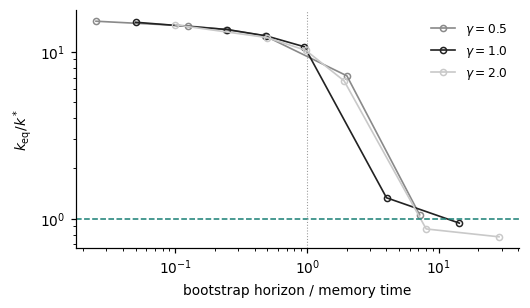

In [8]:
# verification: k_eq(lambda) collapses when the horizon covers the memory
import lstd_lambda as L
lams = [0.0, 0.8, 0.9, 0.95, 0.99, 0.999]
fig, ax = plt.subplots(figsize=(5.2, 2.8))
for g, c in ((0.5, "#8a8a8a"), (1.0, INK), (2.0, "#c9c9c9")):
    ke = [float(np.atleast_1d(L.k_eq_lambda(g, 0.09, l))[0]) for l in lams]
    hor = [1/(1-np.exp(-0.05*0.05)*l) * g * 0.05 for l in lams]   # horizon / memory time
    ax.plot(hor, np.array(ke)/1.65, "o-", ms=4, lw=1.1, color=c, mfc="none",
            label=f"$\\gamma={g}$")
ax.axhline(1, color=TEAL, ls="--", lw=1); ax.axvline(1, color=GREY, ls=":", lw=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("bootstrap horizon / memory time"); ax.set_ylabel(r"$k_{\rm eq}/k^*$")
ax.legend(frameon=False, fontsize=8); plt.show()

## 10. How accurate must a belief be to repair learning?

**Setting.** The natural fix for the learning bias of §8 is to give the critic an estimate of the hidden mode, a belief feature $\tilde z = z + \varepsilon$. This is the *asymmetric actor–critic* of sim-to-real RL [P17]: the critic sees privileged information, the actor sees only what is deployable. Prior theory is qualitative — state-based critics are biased under partial observability [BA21], asymmetric critics remove aliasing terms [AAC25] — but does not say *how accurate the belief must be*. We give the exact threshold.

**Mechanism.** The key point is that TD learning never uses the belief directly; it uses the belief's *change over one step*, because bootstrapping subtracts consecutive value estimates [S88]. Two properties of the belief error then matter, not its size alone: its variance $R_b$ and its correlation time $\tau_\varepsilon$. Rapidly-fluctuating ("fresh") error changes every step and passes through the subtraction intact. Slowly-varying ("smooth") error is nearly the same at $t$ and $t{+}h$, so it cancels in the difference. What the error competes against is the genuine new information about $z$ arriving each step, which has variance $\sigma^2 h$. Hence the critic tolerates a large but smooth error and is harmed by a small but fresh one.

**Proposition 6 (repair threshold; form derived, constant empirical).** 



For a belief error of variance $R_b$ and correlation time $\tau_\varepsilon$, the one-step differenced error has variance $2R_b\bigl(1-e^{-h/\tau_\varepsilon}\bigr)$, which is $\approx 2R_b$ when $\tau_\varepsilon \lesssim h$ (fresh) and $\approx 2R_b\,h/\tau_\varepsilon$ when $\tau_\varepsilon \gtrsim h$ (smooth). Requiring this to stay below the per-step signal $\sigma^2 h$, the belief repairs the learning channel only if
$$R_b \;\lesssim\; \kappa\,\sigma^2\,\max(h,\tau_\varepsilon).$$
The $\max(h,\tau_\varepsilon)$ shape follows from the two regimes above; the prefactor $\kappa \approx 0.05$ is measured at the default instance and not yet derived.

**Consequences.** 

The threshold is sharp. At the default instance, fresh error of order half a percent of $\Sigma_{zz}$ already removes most of the repair, while smooth error tens of times larger is harmless. This separates belief estimators cleanly: Kalman filters and recurrent estimators produce smooth error and are robust, whereas per-step-fresh error — sensor noise on the privileged critic, a stochastically regularised encoder — can negate the belief entirely, and does so more easily at high control frequency (small $h$). Finally, the threshold is relaxed by the bootstrap parameter of §9: averaging targets over $(1-\lambda)^{-1}$ steps attenuates fresh error, so larger $\lambda$ widens the tolerable $R_b$ — consistent with the observed robustness of high-$\lambda$ asymmetric critics.

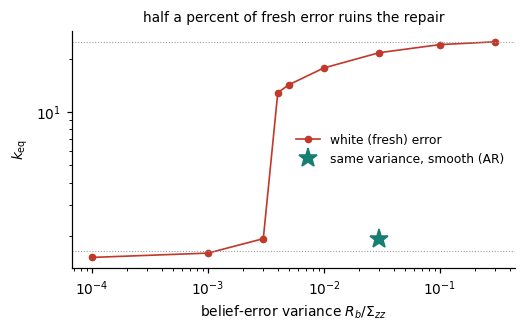

In [9]:
# verification: the cliff, computed exactly (white error), with the smooth-error contrast
import restoration as Rst
Szz = T.TH * T.CC
ratios = [1e-4, 1e-3, 0.003, 0.004, 0.005, 0.01, 0.03, 0.1, 0.3]
ks = [Rst.k_eq_noisy(1.0, T.S_E, r*Szz) for r in ratios]
fig, ax = plt.subplots(figsize=(5.2, 2.8))
ax.plot(ratios, ks, "o-", color=RED, ms=4, lw=1.1, label="white (fresh) error")
ax.plot([0.03], [1.92], "*", ms=13, color=TEAL, label="same variance, smooth (AR)")
ax.axhline(24.8, color=GREY, ls=":", lw=0.7); ax.axhline(1.65, color=GREY, ls=":", lw=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"belief-error variance $R_b/\Sigma_{zz}$")
ax.set_ylabel(r"$k_{\rm eq}$")
ax.legend(frameon=False, fontsize=8)
ax.set_title("half a percent of fresh error ruins the repair", fontsize=9)
plt.show()

## References

- **[SB18]** R. Sutton, A. Barto. *Reinforcement Learning: An Introduction* (2nd ed.), MIT Press, 2018.
- **[KLC98]** L. Kaelbling, M. Littman, A. Cassandra. Planning and acting in partially observable stochastic domains. *Artificial Intelligence* 101, 1998.
- **[K60]** R. E. Kalman. A new approach to linear filtering and prediction problems. *J. Basic Eng.* 82, 1960.
- **[A65]** K. J. Åström. Optimal control of Markov processes with incomplete state information. *J. Math. Anal. Appl.* 10, 1965.
- **[MZ]** H. Mori. Transport, collective motion, and Brownian motion. *Prog. Theor. Phys.* 33, 1965; R. Zwanzig. Memory effects in irreversible thermodynamics. *Phys. Rev.* 124, 1961.
- **[I18]** L. Isserlis. On a formula for the product-moment coefficient of any order of a normal frequency distribution. *Biometrika* 12, 1918.
- **[Wi50]** G. C. Wick. The evaluation of the collision matrix. *Phys. Rev.* 80, 1950.
- **[S88]** R. Sutton. Learning to predict by the methods of temporal differences. *Machine Learning* 3, 1988.
- **[W92]** R. Williams. Simple statistical gradient-following algorithms for connectionist reinforcement learning. *Machine Learning* 8, 1992.
- **[KT00]** V. Konda, J. Tsitsiklis. Actor-critic algorithms. *NeurIPS*, 2000.
- **[S15]** J. Schulman, P. Moritz, S. Levine, M. Jordan, P. Abbeel. High-dimensional continuous control using generalized advantage estimation. arXiv:1506.02438, 2015.
- **[S17]** J. Schulman, F. Wolski, P. Dhariwal, A. Radford, O. Klimov. Proximal policy optimization algorithms. arXiv:1707.06347, 2017.
- **[SJJ94]** S. Singh, T. Jaakkola, M. Jordan. Learning without state-estimation in partially observable Markovian decision processes. *ICML*, 1994.
- **[PM98]** M. Pendrith, M. McGarity. An analysis of direct reinforcement learning in non-Markovian domains. *ICML*, 1998.
- **[PP02]** T. Perkins, M. Pendrith. On the existence of fixed points for Q-learning and Sarsa in partially observable domains. *ICML*, 2002.
- **[B95]** L. Baird. Residual algorithms: reinforcement learning with function approximation. *ICML*, 1995.
- **[TVR97]** J. Tsitsiklis, B. Van Roy. An analysis of temporal-difference learning with function approximation. *IEEE TAC* 42, 1997.
- **[TR18]** S. Tu, B. Recht. Least-squares temporal difference learning for the linear quadratic regulator. *ICML*, 2018 (arXiv:1712.08642).
- **[P17]** L. Pinto, M. Andrychowicz, P. Welinder, W. Zaremba, P. Abbeel. Asymmetric actor critic for image-based robot learning. *RSS*, 2018 (arXiv:1710.06542).
- **[BA21]** A. Baisero, C. Amato. Unbiased asymmetric reinforcement learning under partial observability. *AAMAS*, 2022 (arXiv:2105.11674).
- **[AAC25]** A theoretical justification for asymmetric actor-critic algorithms. *ICML*, 2025 (arXiv:2501.19116).
- **[FP21]** I. Fatkhullin, B. Polyak. Optimizing static linear feedback: gradient method. *SIAM J. Control Optim.*, 2021 (arXiv:2109.13132).
- **[Z21]** S. Zhang, R. Laroche, H. van Seijen, S. Whiteson, R. Tachet des Combes. A deeper look at discounting mismatch in actor-critic algorithms. arXiv:2010.01069, 2020.
- **[CHS24]** S. Cayci, N. He, R. Srikant. Finite-time analysis of natural actor-critic for POMDPs. *SIAM J. Math. Data Sci.*, 2024 (arXiv:2202.09753).


